# <span style="color:black; font-weight:bold;">Cross-omics alignment Mouse Brain Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Cross-omics Mouse Brain data used in the tutorial are available at [RIBOmap_rep2.h5ad](https://drive.google.com/file/d/1Ez-YFtZAS_53Q7ruONyFGxSwVgNYVyI5/view?usp=sharing) , [STARmaprep2.h5ad](https://drive.google.com/file/d/1tSQUlWE5S38vBZ9iUGVntk4uuugDAO5P/view?usp=sharing). The original data is from [CAST](https://doi.org/10.1038/s41592-024-02410-7) in Nature Methods.
In this tutorial we apply MAPS to align RIBOmap to STARmap Mouse Brain Sample dataset

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">RIBOmap</span>: 58,692 cells and 5413 genes   
+ <span style="color:black; font-weight:bold;">STARmap</span>: 59,165 cells and 5413 genes  

In [1]:
from MAPS.align import Rigid_alignment
from MAPS.utils import set_seed,rotate_and_translate_spatial,create_new_color_dict,plot_2d_alignment_to_3d_flow
from MAPS.Evaluation import evaluation
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(2026)

## <span style="color:black; font-weight:bold;">Loading Cross-omics Mouse Brain data</span>

In [4]:
source_adata=sc.read_h5ad('/home/dbj/LPFoundation/RIBOmap/RIBOmap_rep2.h5ad')
source_adata.obs['batch']='RIBOmap'

target_adata=sc.read_h5ad('/home/dbj/LPFoundation/RIBOmap/STARmaprep2.h5ad')
target_adata.obs['batch']='STARmap'

### Rotate and translate the RIBOmap mouse brain

In [5]:
rotate_and_translate_spatial(source_adata,angle_deg=90,dx=15000,dy=2300)

## <span style="color:black; font-weight:bold;">Spatial mapping of the mouse brain before alignment</span>

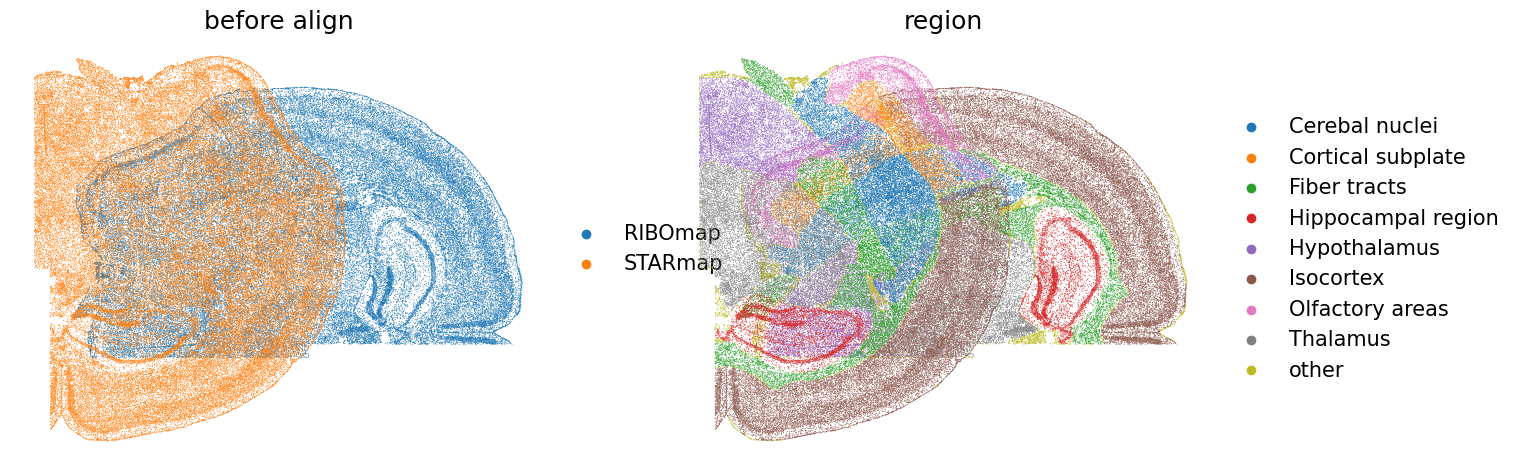

In [6]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (7,5.5)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','region'],title='before align',size=2,frameon=False)

## <span style="color:black; font-weight:bold;">Align the slices using MAPS</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  

### <span style="color:black; font-weight:bold;">Output</span>   
+ aligned_spatial: The coordinates of the source slices after alignment  
+ theta_deg: Angle of rotation  
+ translation: Translation matrix  
+ scale: Scaling factorices

In [7]:
%%time
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)  

aligned_spatial, theta_deg, translation,scale= Rigid_alignment(source, target, epochs=4000, sample_size=10000,enable_scale=False,device=device)
source_adata.obsm['spatial'] = aligned_spatial

Scanning angles to find best starting angle...


Global Align: 100%|████████████████████████████| 4000/4000 [00:21<00:00, 188.73it/s, Loss=195.46, Scale=1.000, Rot=-89.89°, Trans=(-15154.1, -2323.5)]


Peak GPU memory usage: 1.244 GB
Scale factor: 1.000, Rotation angle: -89.44°, Translation (x, y): (-15155.18, -2322.31)
CPU times: user 20 s, sys: 6.23 s, total: 26.3 s
Wall time: 28.9 s


## <span style="color:black; font-weight:bold;">Spatial mapping of the mouse brain after alignment</span>

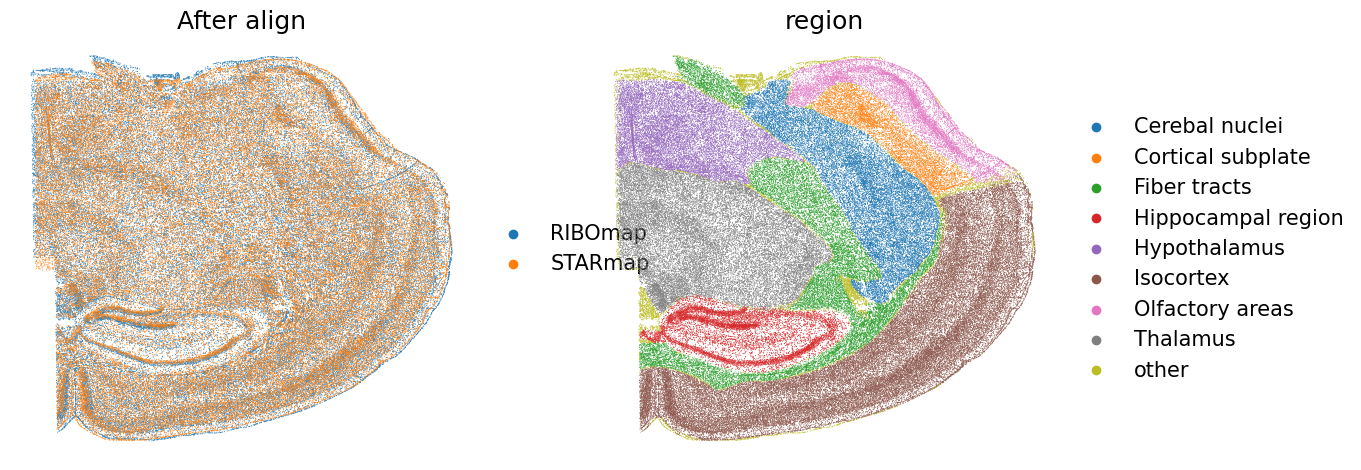

In [8]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,5.5)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','region'],title='After align',size=2,frameon=False)

## <span style="color:black; font-weight:bold;">Cell type matching index(CI)</span>

In [9]:
CI=evaluation(source_adata.obsm['spatial'],target_adata.obsm['spatial'],source_adata.obs['region'],target_adata.obs['region'])
CI

0.9612777824727458

## <span style="color:black; font-weight:bold;">Visualization of the 3D alignment flow</span>

Connected sampling (total 200):
   - Correct pairing (Black): 191
   - Incorrect pairing (red): 9


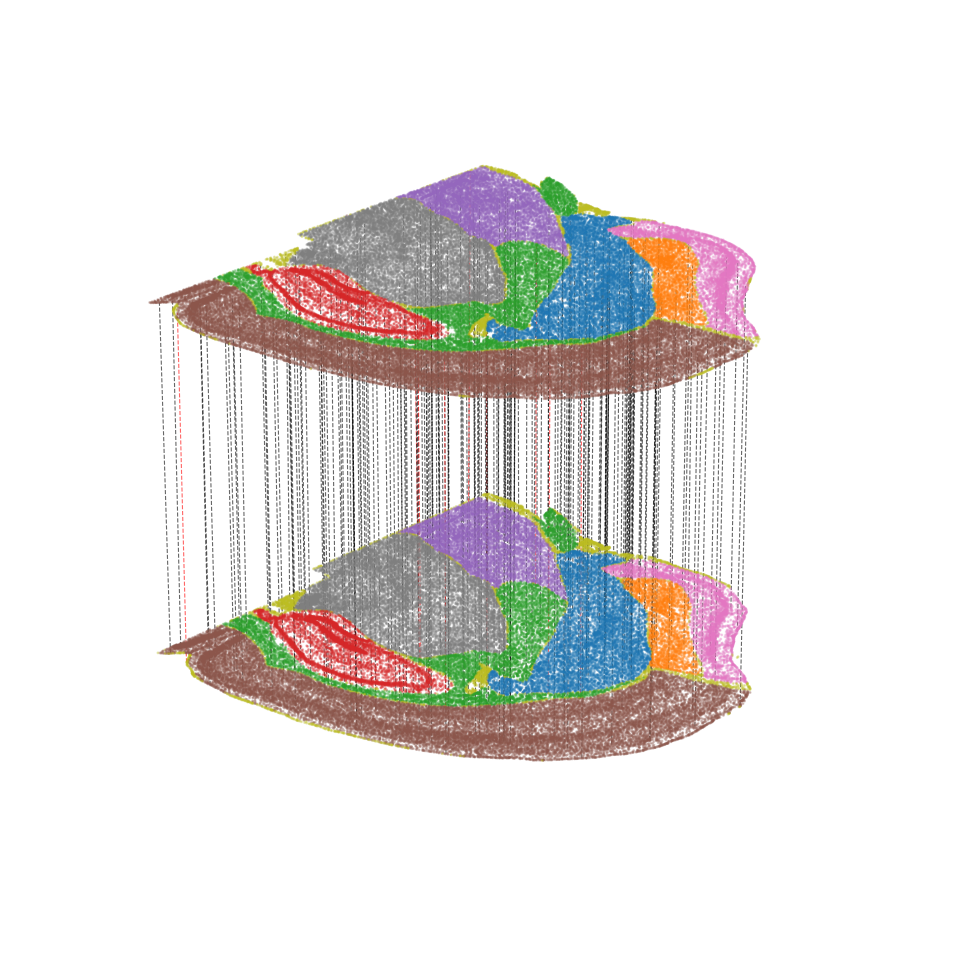

In [10]:
categories = adata.obs['region'].cat.categories
colors = adata.uns['region_colors']  
color_dict = dict(zip(categories, colors))


plot_2d_alignment_to_3d_flow(
    source_adata=source_adata,
    target_adata=target_adata,
    label_key='region',        
    palette=color_dict,        
    n_lines=200,   #samples n lines             
    height_scale=1.0,
    alpha_points=0.3,
    size=1.2,                  
    #save_path='/home/dbj/LPcross/Data/result/RIBOmap_align/alignment_flow_3d.png'
)

## <span style="color:black; font-weight:bold;">The correct alignment ratios for different regions</span>

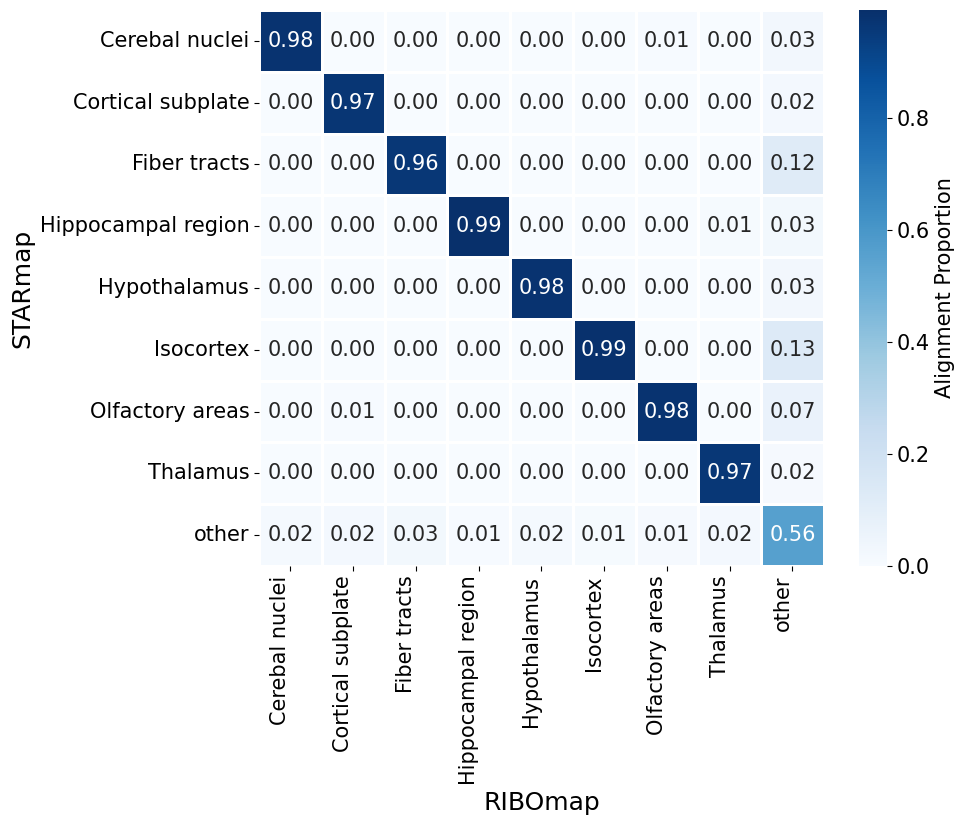

In [13]:
from scipy.spatial import cKDTree
import seaborn as sns
source_label_key = 'region' 
target_label_key = 'region'
source_coords = source_adata.obsm['spatial']  
target_coords = target_adata.obsm['spatial']

tree = cKDTree(target_coords)
distances, indices = tree.query(source_coords, k=1)

source_labels = source_adata.obs[source_label_key].values
matched_target_labels = target_adata.obs[target_label_key].iloc[indices.flatten()].values

df_crosstab = pd.crosstab(
    index=pd.Series(matched_target_labels, name='Target Labels (Y)'),
    columns=pd.Series(source_labels, name='Source Labels (X)'),
    normalize='columns' 
)

plt.figure(figsize=(10, 8.5))
sns.heatmap(df_crosstab, annot=True,cmap='Blues',fmt='.2f',linewidths=1, cbar_kws={'label': 'Alignment Proportion'})
plt.grid(False) 
plt.title('', fontsize=14, pad=15)
plt.xlabel('RIBOmap', fontsize=18)
plt.ylabel('STARmap', fontsize=18)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()